
# Trabajo práctico 1
## Diferencias finitas - Ecuaciones diferenciales ordinarias (EDO)



## Ejercicio 1

Suponga que, como efecto colateral de las vacaciones, se ha olvidado la derivada del $\sin (x)$.
* Calcúlela en $x=\pi/6$, usando las fórmulas de diferencias finitas a $\mathcal{O}(h)$ (adelantada), $\mathcal{O}(h^2)$ (centrada) y $\mathcal{O}(h^4)$ (también centrada).
* Grafique el error
$$
\epsilon = \left|\frac{d\sin (x)}{dx} - \cos (x)\right|
$$
en función de $h$ usando precisión simple y doble (Conviene graficar en $\log-\log$.)

* ¿Para qué valores de $h$ domina el error de redondeo?
* ¿Para qué valores de $h$ domina el error de truncamiento?

El error de redondeo viene de la precisión de la representación de los números en la computadora. El error de truncamiento se refiere a los términos de la serie de Taylor que se truncan al derivar la expresión de la derivada en diferencias finitas.

In [44]:
import numpy as np


def der1(f,x,h=1e-5):
    """Compute the first derivative of a function at point x using central difference."""
    return (f(x + h) - f(x)) / h

def der2(f,x,h=1e-5):
    """Compute the first derivative of a function at point x using central difference at second order."""    
    return (f(x + h) - f(x - h)) / (2 * h)

def der4(f,x,h=1e-5):
    """Compute the first derivative of a function at point x using central difference at fourth order."""
    return (f(x - 2*h) - 8*f(x - h) + 8*f(x + h) - f(x + 2*h)) / (12 * h)

f = lambda x: np.sin(x)

x = np.pi / 6 

 # Example point
print("First derivative (1st order):", der1(f, x))
print("First derivative (2nd order):", der2(f, x))
print("First derivative (4th order):", der4(f, x))

# Create a logarithmic scale of h values
h_values = np.logspace(-10, -1, num=30)

# Compute the derivatives for each h
der1_values = [der1(f, x, h) for h in h_values]
der2_values = [der2(f, x, h) for h in h_values]
der4_values = [der4(f, x, h) for h in h_values]


First derivative (1st order): 0.8660229037615873
First derivative (2nd order): 0.8660254037645697
First derivative (4th order): 0.8660254037775224


In [49]:
# Compute the errors analytically
true_derivative = np.cos(x)
error_der1 = 0.5 * h_values * np.abs(np.sin(x))  # O(h)
error_der2 = (1/6) * h_values**2 * np.abs(np.cos(x))  # O(h^2)
error_der4 = (1/30) * h_values**4 * np.abs(np.sin(x))  # O(h^4)

In [75]:
# Compute the precision limit due to floating-point arithmetic
epsilon = np.finfo(float).eps
precision_limit = epsilon / h_values


In [ ]:

# Compute the value when the precision limit intersects the error curves
precs_limit_der1 = np.abs(np.array(der1_values) - np.cos(x)) < precision_limit
precs_limit_der2 = np.abs(np.array(der2_values) - np.cos(x)) < precision_limit
precs_limit_der4 = np.abs(np.array(der4_values) - np.cos(x)) < precision_limit

intersect_der1 = np.max(h_values[np.where(precs_limit_der1)])
intersect_der2 = np.max(h_values[np.where(precs_limit_der2)])
intersect_der4 = np.max(h_values[np.where(precs_limit_der4)])

In [51]:
print("Intersection h for der1:", intersect_der1)
print("Intersection h for der2:", intersect_der2)
print("Intersection h for der4:", intersect_der4)

Intersection h for der1: 1.4873521072935118e-08
Intersection h for der2: 9.236708571873865e-06
Intersection h for der4: 0.0013738237958832637


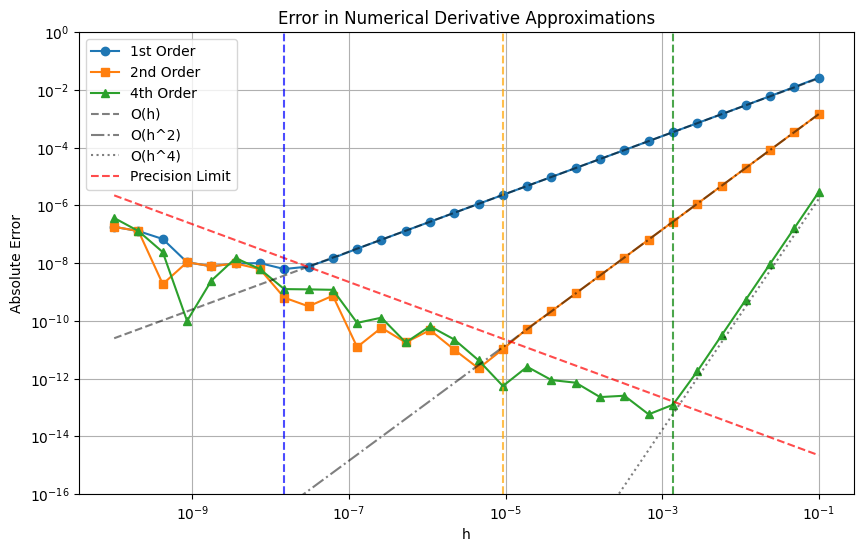

In [ ]:

# Plotting the results
import matplotlib.pyplot as plt 
plt.figure(figsize=(10, 6))
plt.loglog(h_values, np.abs(np.array(der1_values) - np.cos(x)), label='1st Order', marker='o')
plt.loglog(h_values, np.abs(np.array(der2_values) - np.cos(x)), label='2nd Order', marker='s')
plt.loglog(h_values, np.abs(np.array(der4_values) - np.cos(x)), label='4th Order', marker='^')
# Plot the theoretical error lines
plt.loglog(h_values, error_der1, 'k--', label='O(h)', alpha=0.5)
plt.loglog(h_values, error_der2, 'k-.', label='O(h^2)', alpha=0.5)
plt.loglog(h_values, error_der4, 'k:', label='O(h^4)', alpha=0.5)
# Plot the precision limit
plt.loglog(h_values, precision_limit, 'r--', label='Precision Limit', alpha=0.7)
# Plot the intersection points as vertical lines
if intersect_der1:
    plt.axvline(intersect_der1, color='blue', linestyle='--', alpha=0.7)
if intersect_der2:
    plt.axvline(intersect_der2, color='orange', linestyle='--', alpha=0.7)
if intersect_der4:
    plt.axvline(intersect_der4, color='green', linestyle='--', alpha=0.7)
    
plt.xlabel('h')
plt.ylabel('Absolute Error')
plt.ylim(1e-16, 1)
plt.title('Error in Numerical Derivative Approximations')
plt.legend()
plt.grid(True)
plt.show()


In [79]:
# import the arbitrary precision library
from mpmath import mp

# set the precision (number of decimal places)
mp.dps = 40  # you can adjust this value as needed

def der1_high_prec(f, x, h=mp.mpf('1e-5')):
    """Compute the first derivative of a function at point x using central difference with high precision."""
    return (f(x + h) - f(x)) / h
def der2_high_prec(f, x, h=mp.mpf('1e-5')):
    """Compute the first derivative of a function at point x using central difference at second order with high precision."""    
    return (f(x + h) - f(x - h)) / (2 * h)
def der4_high_prec(f, x, h=mp.mpf('1e-5')):
    """Compute the first derivative of a function at point x using central difference at fourth order with high precision."""
    return (f(x - 2*h) - 8*f(x - h) + 8*f(x + h) - f(x + 2*h)) / (12 * h)

f_high_prec = lambda x: mp.sin(x)
x_high_prec = mp.mpf(mp.pi) / mp.mpf(6)  # Example point
print("High Precision First derivative (1st order):", der1_high_prec(f_high_prec, x_high_prec))
print("High Precision First derivative (2nd order):", der2_high_prec(f_high_prec, x_high_prec))
print("High Precision First derivative (4th order):", der4_high_prec(f_high_prec, x_high_prec))


High Precision First derivative (1st order): 0.8660229037700049108673880286877448846483
High Precision First derivative (2nd order): 0.8660254037700048900340546954238559953445
High Precision First derivative (4th order): 0.8660254037844386467634344956183448072941


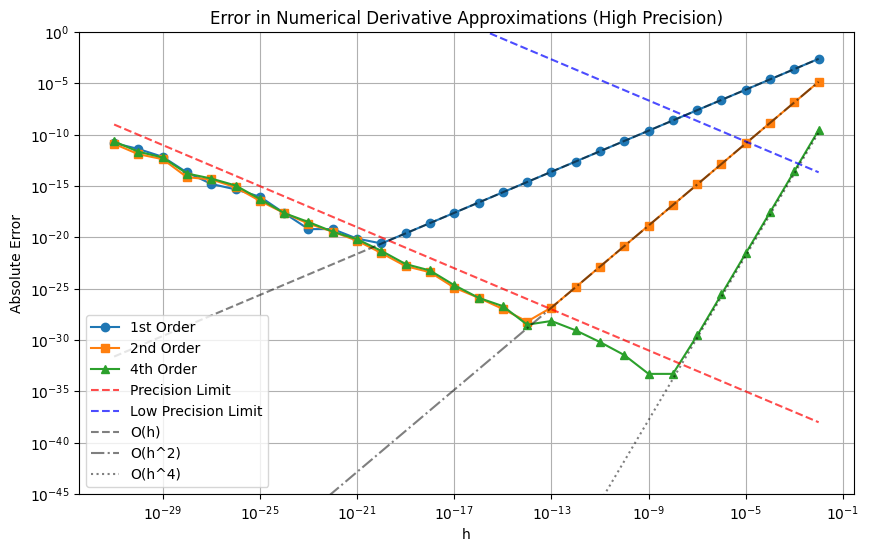

In [80]:
# Create a logarithmic scale of h values with high precision with mp.mpf
h_values = [mp.mpf(10)**(-i) for i in range(31, 1, -1)]

# Compute the derivatives for each h
der1_values = [der1_high_prec(f_high_prec, x_high_prec, h) for h in h_values]
der2_values = [der2_high_prec(f_high_prec, x_high_prec, h) for h in h_values]
der4_values = [der4_high_prec(f_high_prec, x_high_prec, h) for h in h_values]

# Compute the errors analytically
true_derivative = np.cos(x)
error_der1 = [0.5 * float(h) * np.abs(np.sin(x)) for h in h_values]  # O(h)
error_der2 = [(1/6) * float(h)**2 * np.abs(np.cos(x)) for h in h_values]  # O(h^2)
error_der4 = [(1/30) * float(h)**4 * np.abs(np.sin(x)) for h in h_values]  # O(h^4)

# Compute the precision limit due to floating-point arithmetic
high_precision_limit = [mp.mpf(10)**(-mp.dps) / h for h in h_values]

# Plotting the results
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.loglog(h_values, [mp.fabs(der - mp.cos(x_high_prec)) for der in der1_values], label='1st Order', marker='o')
plt.loglog(h_values, [mp.fabs(der - mp.cos(x_high_prec)) for der in der2_values], label='2nd Order', marker='s')
plt.loglog(h_values, [mp.fabs(der - mp.cos(x_high_prec)) for der in der4_values], label='4th Order', marker='^')

# Plot the precision limit
plt.loglog(h_values, high_precision_limit, 'r--', label='Precision Limit', alpha=0.7)
# plot the low precision limit
plt.loglog(h_values, precision_limit, 'b--', label='Low Precision Limit', alpha=0.7)

# Plot the theoretical error lines  
plt.loglog(h_values, error_der1, 'k--', label='O(h)', alpha=0.5)
plt.loglog(h_values, error_der2, 'k-.', label='O(h^2)', alpha=0.5)
plt.loglog(h_values, error_der4, 'k:', label='O(h^4)', alpha=0.5)
plt.xlabel('h')
plt.ylabel('Absolute Error')  
plt.ylim(1e-45, 1)      
plt.title('Error in Numerical Derivative Approximations (High Precision)')
plt.legend()
plt.grid(True)
plt.show()

##Ejercicio 2

Usando el método de Euler, integre las ecuaciones de movimiento del oscilador armónico:
$$
\begin{align}
\frac{dx}{dt}=p,~~~~\frac{dp}{dt}=-x.
\end{align}
$$
Elija la condición inicial $x(0) = 1$, $p(0) = 1$ y resuelva hasta un tiempo fijo $t = 42$, empleando distintos pasos de tiempo $h$. Grafique la trayectoria en el espacio de fases, y compárela con la trayectoria analítica. Calcule la energía mecánica de la solución numérica en función del paso de tiempo, y compárela con la verdadera.



##Ejercicio 3


Considere el siguiente modelo de un sistema de reacciones químicas:
\begin{align}
\frac{dx}{dt} &= a - (b+1) x + x^2 y, \\
\frac{dy}{dt} &= b\,x - x^2 y,
\end{align}
donde $x$ e $y$ son las concentraciones, y $a$ y $b$ son parámetros. Resuelva numéricamente el sistema con un método RK4, y grafique las trayectorias en el espacio de fases $(x,y)$. Considere los siguientes casos.
1. Para $a=b=1$, y usando pasos $h=0.1$, $0.2$, $0.5$ y $1.0$, muestre numéricamente que las soluciones numéricas convergen al equilibrio, incluso para los pasos grandes.
2. Para $a=1$, $b=3$, muestre (numéricamente) que el equilibrio es inestable y que las trayectorias tienden a un ciclo límite. Pruebe distintas condiciones iniciales (tanto dentro del ciclo y cerca del punto fijo, como fuera de él). Use pasos $h=0.1$ y mayores, con cuidado. Verifique que a partir de cierto valor de $h$ las soluciones numéricas divergen.




## Ejercicio 4

Considere un “péndulo elástico”, como aproximación realista de un péndulo
verdadero. El mismo consiste en un resorte de longitud natural $l_0$ y constante
elástica $k$. Uno de sus extremos está fijo, y del otro pende una masa $m$.
Suponga que el movimiento es en un plano, y que el resorte no se dobla
cuando se contrae o estira.
1. Encuentre las ecuaciones de movimiento.
2. Programe una resolución numérica con un método RK4.
3. Grafique trayectorias de la masa en el plano de oscilación, para distintos valores de $k$ (fijando $m$, $l_0$ y $g$). Describa los movimientos que se
observan.
4. Si el resorte es muy duro ($k \gg 1$), el sistema es aproximadamente un
péndulo simple. Grafique la coordenada angular en función del tiempo
para un rango de valores de k, a partir de este régimen. Observe lo que
ocurre con el período de la oscilación.
5. Cuando un péndulo es utilizado dentro de un mecanismo de relojería,
más que el período verdadero (que hace cosas raras, como verá en el punto anterior), lo que realmente interesa es el tiempo entre pasadas consecutivas por la vertical, en la misma dirección. Grafique esta magnitud en
función de k. Discuta lo que ocurre y por qué.

**Nota sobre los parámetros**: Para empezar, le sugerimos $k = 10$,
$l_0 = 1$, $m = 1$, $g = 10$. Para las condiciones iniciales, considere un
estiramiento del $10\%$ del resorte y una desviación $\theta_0 = 0.1$ radianes, con velocidades iniciales nulas. Para las partes **4** y **5**, manténgase
en el régimen de pequeñas oscilaciones.

**Nota sobre las coordenadas**: Le recomendamos usar las siguientes
coordenadas generalizadas: $r$, estiramiento a partir de $l_0$ , y $\theta$, apartamiento de la vertical.